In [9]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import pingouin as pg
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
data = {
    'Compuesto': ['A', 'A', 'A', 'A', 'A', 'A', 'A', 'A',
                  'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B'],
    'Temperatura': [25, 25, 25, 25, 40, 40, 40, 40,
                    25, 25, 25, 25, 40, 40, 40, 40],
    'Durabilidad': [50, 52, 48, 51, 43, 45, 42, 44,
                    55, 57, 56, 58, 46, 47, 45, 48]
}

df = pd.DataFrame(data)

In [3]:
df

,Compuesto,Temperatura,Durabilidad
0,A,25,50
1,A,25,52
2,A,25,48
3,A,25,51
4,A,40,43
5,A,40,45
6,A,40,42
7,A,40,44
8,B,25,55
9,B,25,57


In [4]:
anova = pg.anova(
    data=df,
    dv='Durabilidad',
    between=['Compuesto', 'Temperatura'],
    detailed=True
).round(4)
anova

,Source,SS,DF,MS,F,p-unc,np2
0,Compuesto,85.5625,1,85.5625,43.2316,0.0000,0.7827
1,Temperatura,280.5625,1,280.5625,141.7579,0.0000,0.9220
2,Compuesto * Temperatura,10.5625,1,10.5625,5.3368,0.0395,0.3078
3,Residual,23.7500,12,1.9792,NaN,NaN,NaN


In [5]:
SST = anova['SS'].sum()
df_total = anova['DF'].sum()

anova.loc[len(anova)] = [
        'Total',
        SST,
        df_total,
        None, None, None, None
    ]
anova



C:\Users\Usuario\AppData\Local\Temp\ipykernel_11172\1599716165.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  anova.loc[len(anova)] = [


,Source,SS,DF,MS,F,p-unc,np2
0,Compuesto,85.5625,1,85.5625,43.2316,0.0000,0.7827
1,Temperatura,280.5625,1,280.5625,141.7579,0.0000,0.9220
2,Compuesto * Temperatura,10.5625,1,10.5625,5.3368,0.0395,0.3078
3,Residual,23.7500,12,1.9792,NaN,NaN,NaN
4,Total,400.4375,15,NaN,NaN,NaN,NaN


In [13]:
print(df.dtypes)


Compuesto      object
Temperatura     int64
Durabilidad     int64
dtype: object


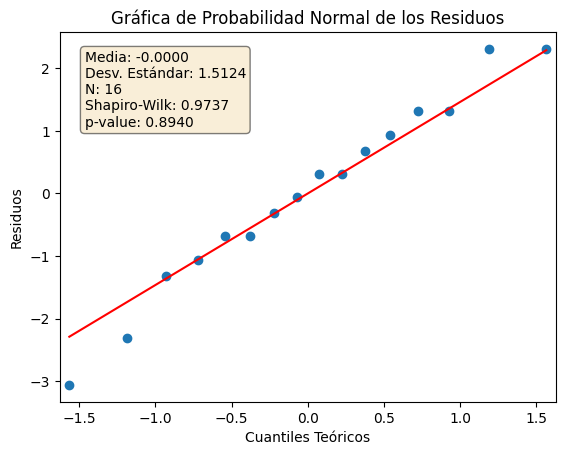

In [22]:
formula = 'Durabilidad ~ C(Compuesto) + C(Temperatura)'
model = sm.formula.ols(formula, data=df).fit()

# Obtener los residuos
residuals = model.resid

# Calcular estadísticas de los residuos
media_residuos = np.mean(residuals)
desv_std_residuos = np.std(residuals, ddof=1)  # Desviación estándar
n_residuos = len(residuals)  # Número de residuos

# Prueba de normalidad de Shapiro-Wilk (devuelve p-value)
shapiro_stat, p_value = stats.shapiro(residuals)

# Crear la gráfica de probabilidad normal
fig, ax = plt.subplots()
sm.qqplot(residuals, line='s', ax=ax)
plt.title('Gráfica de Probabilidad Normal de los Residuos')
plt.xlabel('Cuantiles Teóricos')
plt.ylabel('Residuos')

# Mostrar estadísticas en la gráfica
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
textstr = '\n'.join((
    f'Media: {media_residuos:.4f}',
    f'Desv. Estándar: {desv_std_residuos:.4f}',
    f'N: {n_residuos}',
    f'Shapiro-Wilk: {shapiro_stat:.4f}',
    f'p-value: {p_value:.4f}'
))
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.show()
